# Stage 3 - Exploratory Data Analysis

## 02_eda.ipynb

#### Performs Exploratory Data Analysis (EDA) on the processed South African crime statistics dataset by:

- Loading the `sa_crime_clean` CSV from `data/processed/sa_crime_clean.csv`,
- Producing the four core visualisations comprising the EDA phase, which answer several of the posed research questions, and    
- Exporting and saving all produced charts to `reports/figures/` for subsequent stages in the project pipeline.


#### Data source: [Crime Statistics of South Africa (2011-2023)](https://www.kaggle.com/datasets/harutyunagababyan/crime-stats-of-south-africa-2011-2023)

---------------


Imports necessary libraries: `numpy` and `pandas` for data manipulation; `pyplot`and `mticker` from `matplotlib` and `seaborn` for data visualisation; `os` for directory navigation:  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt               # chart rendering
import matplotlib.ticker as mticker           # chart axis formatting
import seaborn as sns                        
import os      

Navigates from notebook's location to project root, i.e. since notebooks live in `notebooks/`, goes up one level to reach project root:

In [2]:
dir_nb = os.getcwd()
project_root = os.path.dirname(dir_nb) 
os.chdir(project_root)                

print(os.getcwd()) 

C:\Users\Wits-User\Desktop\PROJECTS\sa-crime-statistics


Creates `reports/figures/` directory path if it does not exist:

In [3]:
os.makedirs('reports/figures/', exist_ok = True)

Ensures generated plots are rendered and displayed directly below code:

In [4]:
%matplotlib inline

Sets a consistent visual style for all produced charts:

In [5]:
plt.rcParams.update({
    'font.family'       :  'Arial',
    'figure.dpi'        :  300,
    'axes.spines.top'   :  False,     # hides top chart border lines 
    'axes.spines.right' :  False})    # hides right chart border lines

Provides three options for global formatting of axis tick labels - ensures better readability: 

In [6]:
label_fmt_1 = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')        # option 1 - comma separators
label_fmt_2 = mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}')     # option 2 - millions annotation
label_fmt_3 = mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}')     # option 3 - thousands annotation

Loads processed data from file:

In [7]:
crime_df = pd.read_csv('data/processed/sa_crime_clean.csv')

print('Crime statistics dataset read into dataframe!')

Crime statistics dataset read into dataframe!


Verifies dimensions and column names of `crime_df` for confirmation purposes:

In [8]:
crime_df.shape

(756, 4)

In [9]:
crime_df.columns.tolist()

['province', 'crime_category', 'financial_year', 'incident_count']

##### Visualisation 1 - Total Crimes by Province:   

##### This visual comprises the aggregation of all crime incident counts across all categories and years that produces a single total count per province. 

Groups crime counts to determine crime count totals by province:

In [10]:
province_df = (crime_df.groupby('province')['incident_count']
                       .sum()
                       .sort_values(ascending = True)        # ensures province with largest total is at the top
                       .reset_index())

Produces the first visualisation in the form of a horizontal bar graph:

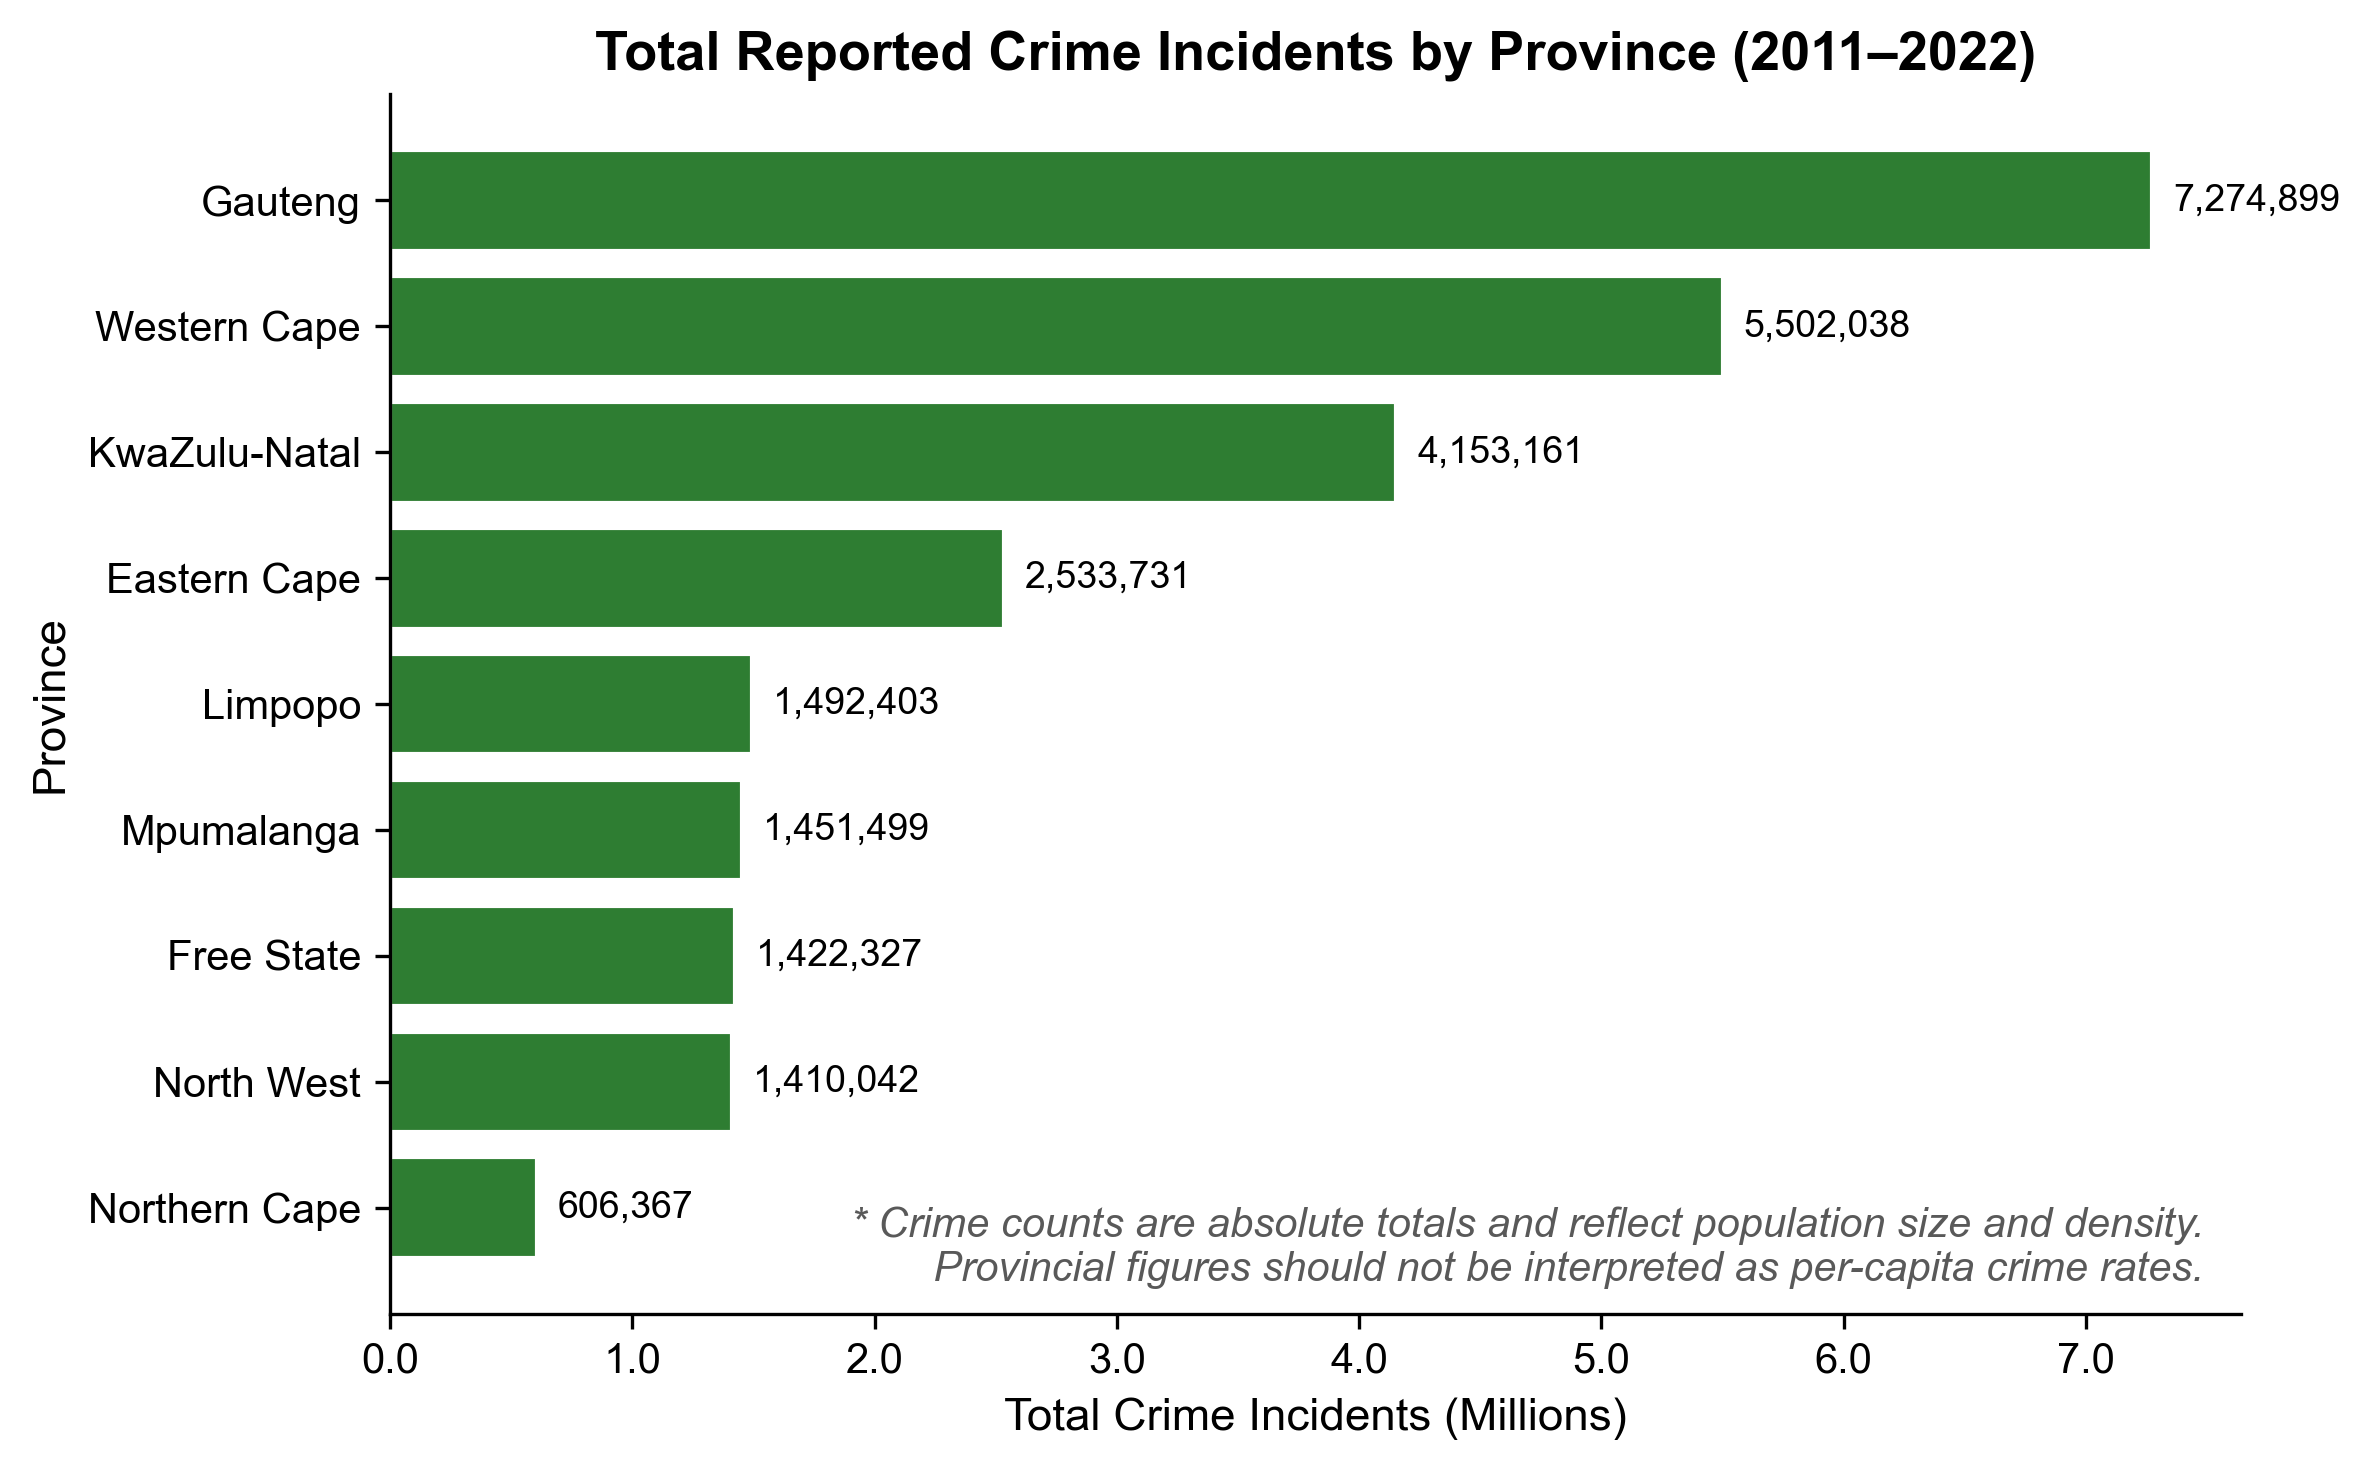

In [11]:
fig1, ax1 = plt.subplots(figsize = (8,5))

chart1_bars = ax1.barh(province_df['province'],              # horizontal bar chart to accomodate full province names
                       province_df['incident_count'], 
                       color = '#2E7D32', 
                       edgecolor = 'white')

bar_labels = []    # initialises bar labels       

# defines bar labels:
for province, count in zip(province_df['province'],province_df['incident_count']):
    bar_labels.append(f'{count:,.0f}')
        
ax1.bar_label(chart1_bars, labels = bar_labels, padding = 5, fontsize = 9)

# adds single text annotation for province totals succeeded by an asterisk:
ax1.text(x = 0.98, y = 0.02,
         s = '* Crime counts are absolute totals and reflect population size and density.\n  Provincial figures should not be interpreted as per-capita crime rates.',
         transform = ax1.transAxes,                          # uses axes coordinates - ignores data scale
         fontsize = 10,
         ha = 'right', va = 'bottom',                        # positions text bottom right of chart
         color = '#595959',
         style = 'italic')

# chart formatting:

ax1.xaxis.set_major_formatter(label_fmt_2)                   # calls global axis tick formatting option 2
ax1.tick_params(axis = 'both', labelsize = 10)
ax1.set_xlabel('Total Crime Incidents (Millions)', fontsize = 11)
ax1.set_ylabel('Province', fontsize = 11)
ax1.set_title('Total Reported Crime Incidents by Province (2011\u20132022)', fontsize = 13, fontweight = 'bold')

plt.tight_layout()                                           # ensures smooth readability
plt.savefig('reports/figures/province_bar_chart.png', dpi = 300, bbox_inches = 'tight')
plt.show()

##### Visualisation 2 - National Crime Trend:   

##### This visual comprises the aggregation of all national crime incident counts by year to display the crime trend across the 12-year window:

Groups crime counts to determine national crime counts by year:

In [12]:
national_df = (crime_df.groupby('financial_year')['incident_count']
                       .sum()
                       .reset_index())

In this step, Numpy `polyfit` is used to fit a linear trendline to the national year crime incidents:

In [13]:
linear_fit = np.polyfit(national_df['financial_year'], national_df['incident_count'], 1)
trendline = np.poly1d(linear_fit)

Produces the second visualisation in the form of a line graph overlaid by a linear trendline:

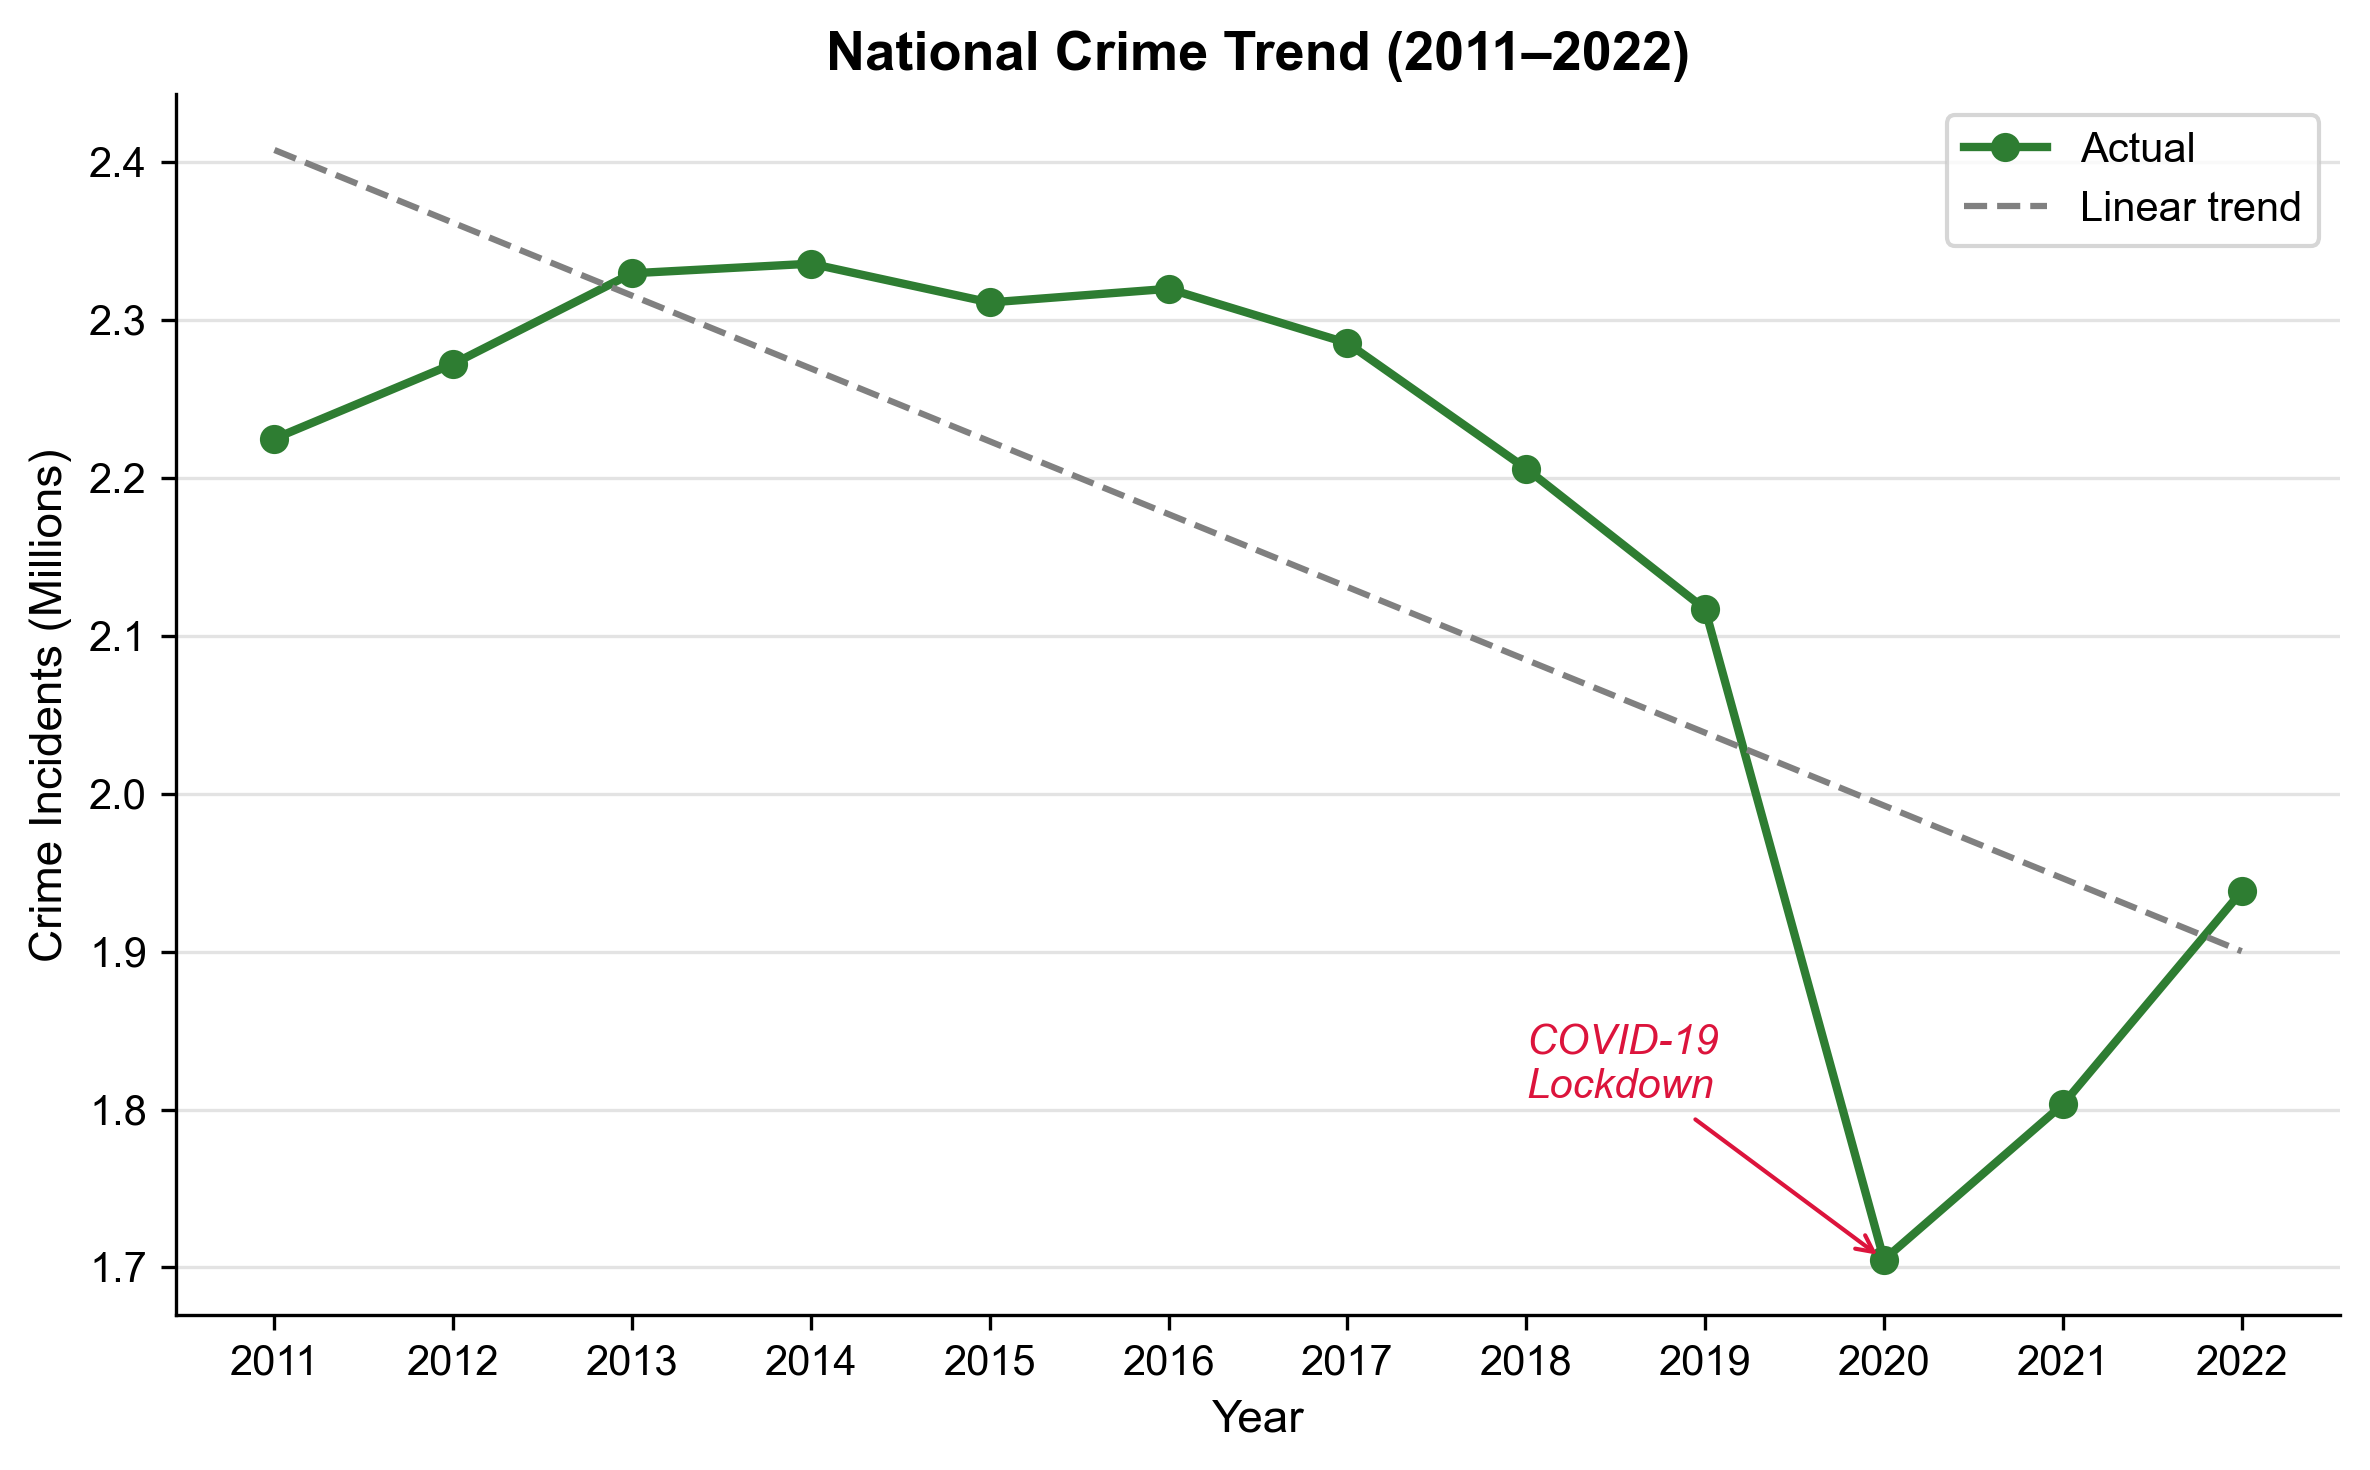

In [14]:
fig2, ax2 = plt.subplots(figsize = (8,5))

# plots a line graph of the national yearly crime incidents:
ax2.plot(national_df['financial_year'],
         national_df['incident_count'],
         marker = 'o', 
         color = '#2E7D32', 
         linewidth = 2, 
         label = 'Actual')

# plots a linear trendline that overlays the national yearly crime incidents:
ax2.plot(national_df['financial_year'], 
         trendline(national_df['financial_year']), 
         linestyle = '--', 
         color = 'grey', 
         linewidth = 1.5, 
         label = 'Linear trend')

# Extracts crime count value corresponding to COVID-19 period for 2020:
covid_count = national_df.loc[national_df['financial_year'] == 2020, 'incident_count'].values[0]

# annotates COVID-19 lockdown period for 2020:
ax2.annotate('COVID-19\nLockdown', 
             xy = (2020, covid_count), 
             xytext = (2018, covid_count*1.06), 
             arrowprops = dict(arrowstyle = '->', color = '#DC143C'), 
             color = '#DC143C', 
             fontsize = 10,
             style = 'italic')

# chart formatting:
ax2.yaxis.set_major_formatter(label_fmt_2)                   # calls upon global axis tick formatting option 2
ax2.set_xticks(national_df['financial_year'])
ax2.tick_params(axis = 'both', labelsize = 10)
ax2.set_xlabel('Year', fontsize = 11)
ax2.set_ylabel('Crime Incidents (Millions)', fontsize = 11)
ax2.set_title('National Crime Trend (2011\u20132022)', fontsize = 13, fontweight = 'bold')
ax2.legend()
plt.grid(axis = 'y', alpha = 0.35)

plt.tight_layout()                                    
plt.savefig('reports/figures/national_crime_trend.png', dpi = 300, bbox_inches = 'tight')
plt.show()

##### Visualisation 3 - Top 5 Categories Over Time:   

##### This visual comprises the aggregation of the top 5 crime categories and their corresponding crime incident totals over the 12-year window:

Groups the crime counts to determine crime count totals by category, and extracts the 5 categories with the highest count totals in the form of a list:

In [15]:
top5_list = (crime_df.groupby('crime_category')['incident_count']
                     .sum()
                     .nlargest(5)              # extracts top 5 five crime categories and corresponding crime totals   
                     .index.tolist())          # extracts only names of the five crime categories

Extracts all row entries that fall under the top 5 crime categories, and groups crime counts to determine crime totals for every year-category pair of the top 5 categories:

In [16]:
category_df = (crime_df[crime_df['crime_category'].isin(top5_list)]                        # extracts all entries with top 5 crime categories
                       .groupby(['financial_year','crime_category'])['incident_count']     # groups entries by year-category pair     
                       .sum()
                       .reset_index())

Produces the third visualisation in the form of a multi-line graph:

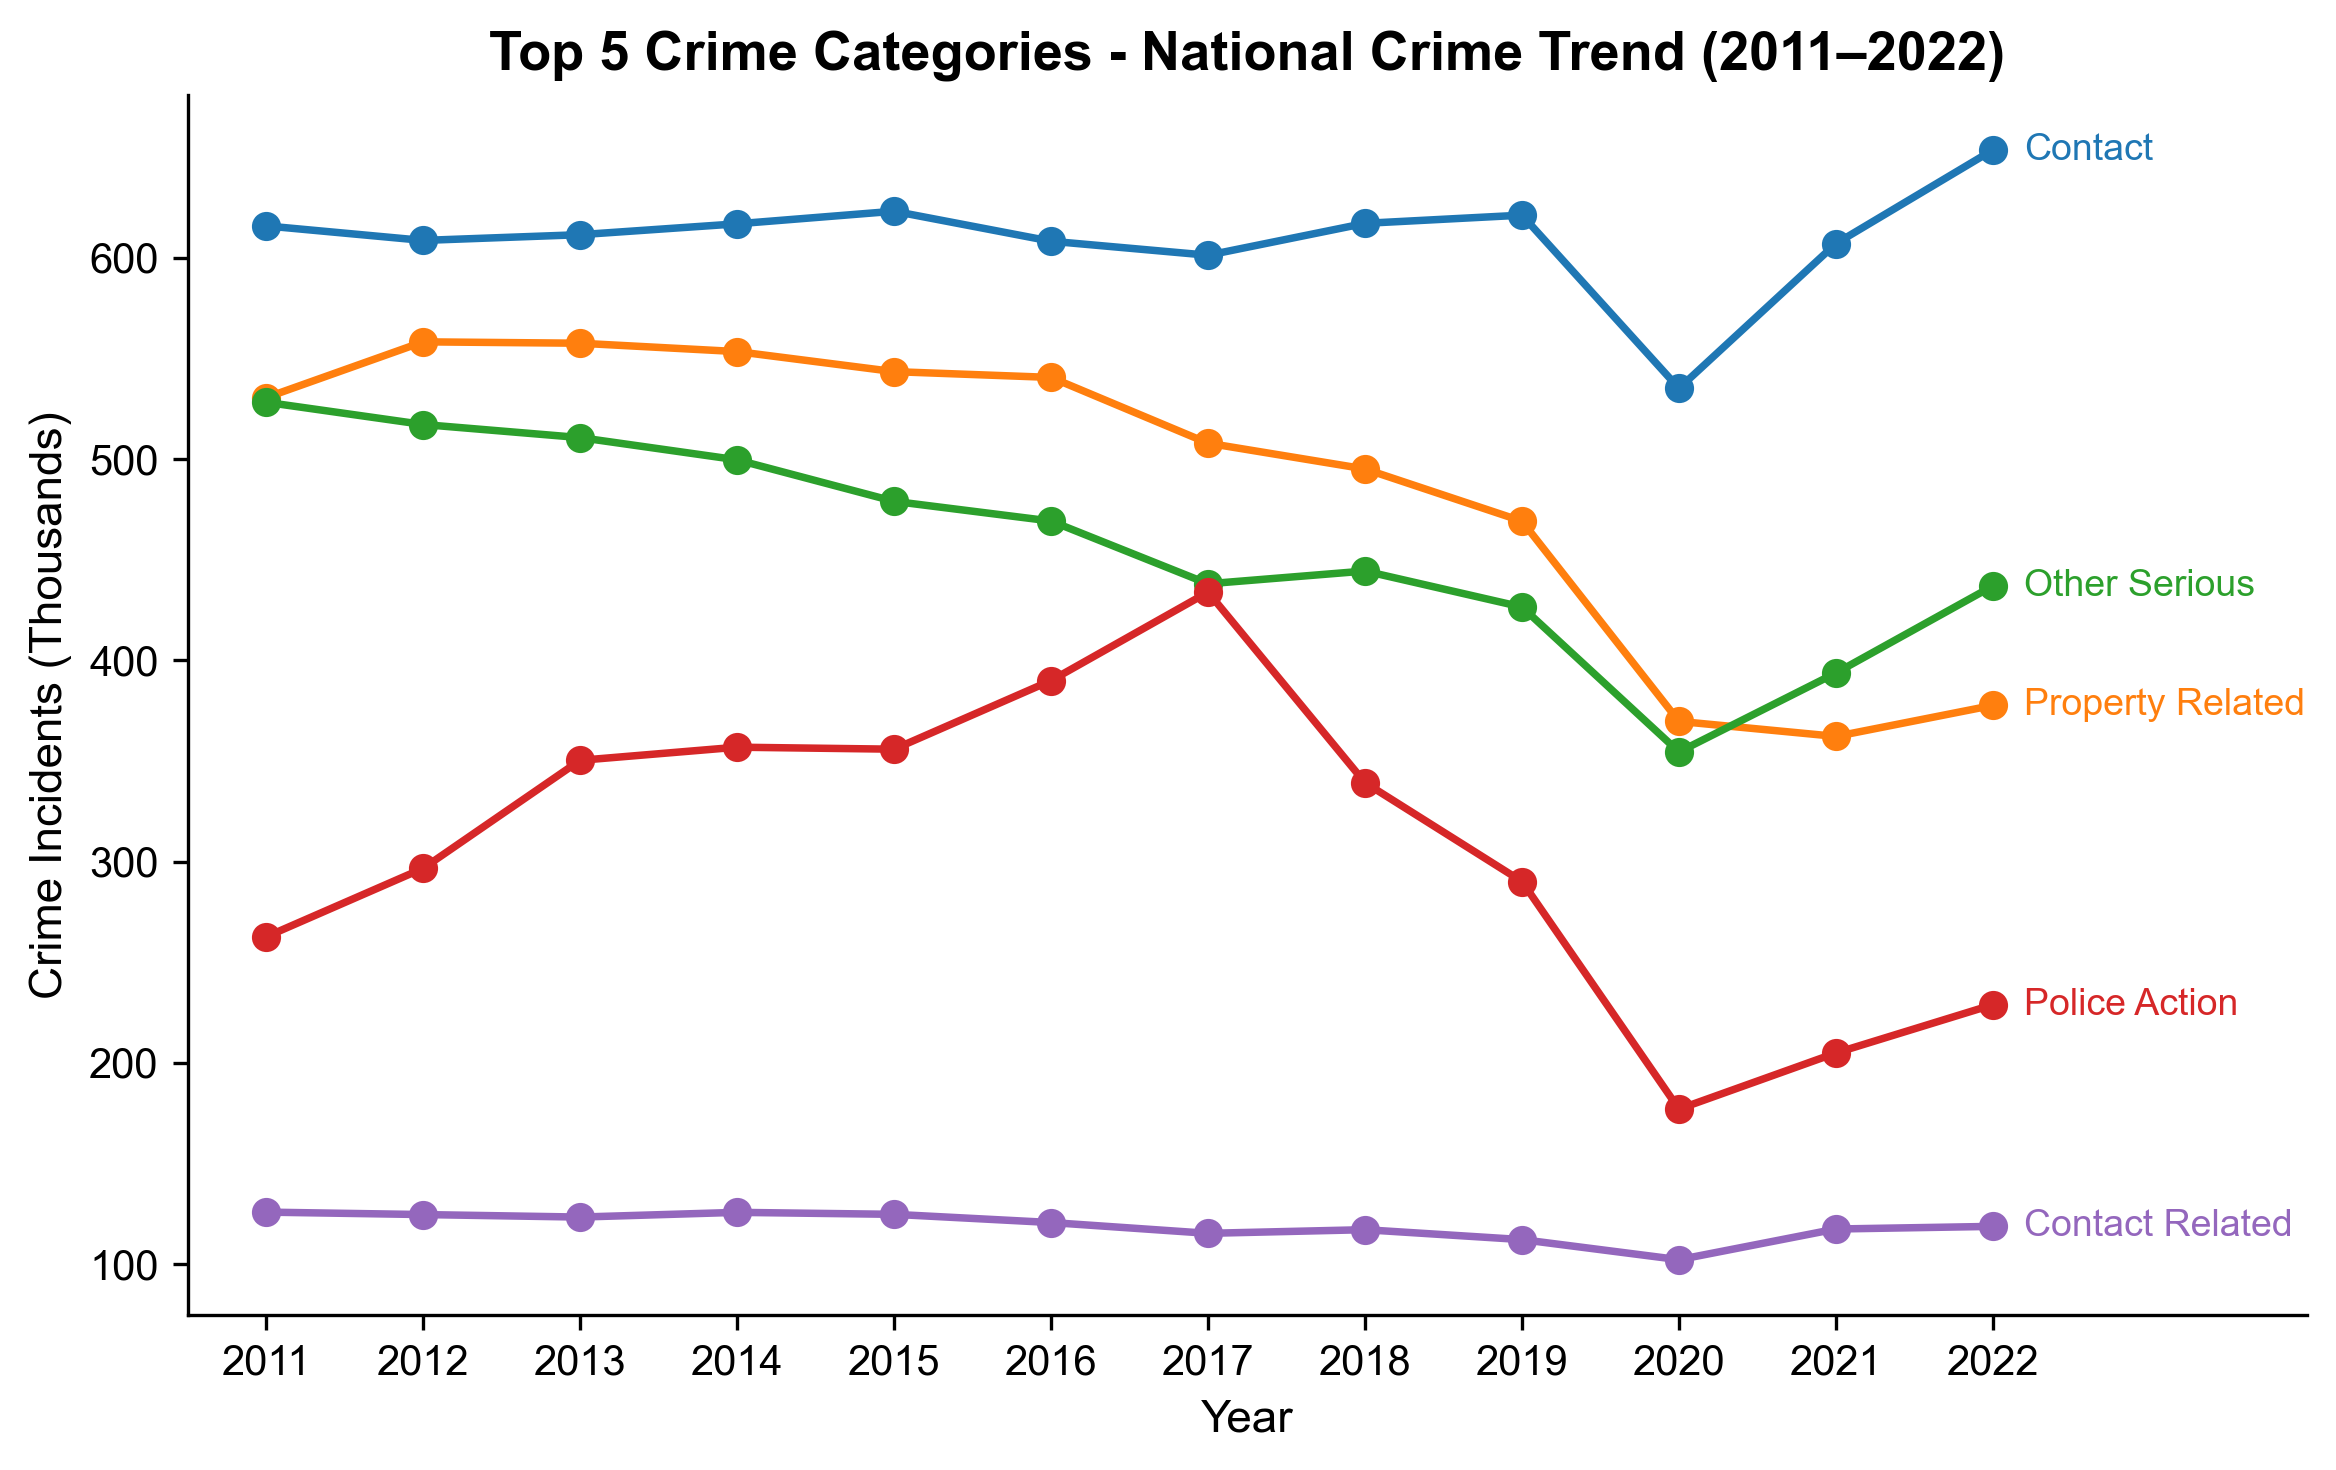

In [17]:
fig3, ax3 = plt.subplots(figsize = (8,5))

# plots individual lines corresponding to categories:
for category in top5_list:
    line = category_df[category_df['crime_category'] == category]
    ax3.plot(line['financial_year'], line['incident_count'], 
             marker = 'o', linewidth = 1.8)

# chart formatting:
ax3.yaxis.set_major_formatter(label_fmt_3)                   # calls global axis tick formatting option 3
ax3.set_xticks(category_df['financial_year'].unique())                 
ax3.set_xlabel('Year', fontsize = 11)
ax3.set_ylabel('Crime Incidents (Thousands)', fontsize = 11)
ax3.set_title('Top 5 Crime Categories - National Crime Trend (2011\u20132022)', fontsize = 13, fontweight = 'bold')

# adds shorter category labels at the end of each line:
for line, label in zip(ax3.lines, top5_list): 
    last_y = line.get_ydata()[-1]                             # extracts last data point from each line
    ax3.text(x = 2022.2,
             y = last_y,
             s = label,
             fontsize = 9,
             color = line.get_color(),
             va = 'center')

ax3.set_xlim(2010.5, 2024)                                 # extends x axis limit to accomodate labels

plt.tight_layout()                                          
plt.savefig('reports/figures/top5_categories.png', dpi = 300, bbox_inches = 'tight')
plt.show()

##### Visualisation 4 - Crime Category x Year Heatmap :   

##### This visual is produced through plotting every crime category against every year, which displays the total counts for every category-year pair.

Groups the crime counts and reshapes dataframe `crime_df` to determine crime totals for every category-year pair:

In [18]:
category_year_df = (crime_df.groupby(['crime_category','financial_year'])['incident_count']
                            .sum()
                            .unstack(fill_value = 0))                 # shifts row index into column headers - creates columns for years

Rearranges rows according to total crime count in descending order:

In [19]:
category_year_df = (category_year_df.loc[category_year_df
                                    .sum(axis = 1)                    # applies summation across columns
                                    .sort_values(ascending = False)   # categories with larger incidents appear first
                                    .index])

Produces the fourth visualisation in the form of a heatmap with a Blue-Green colourmap:

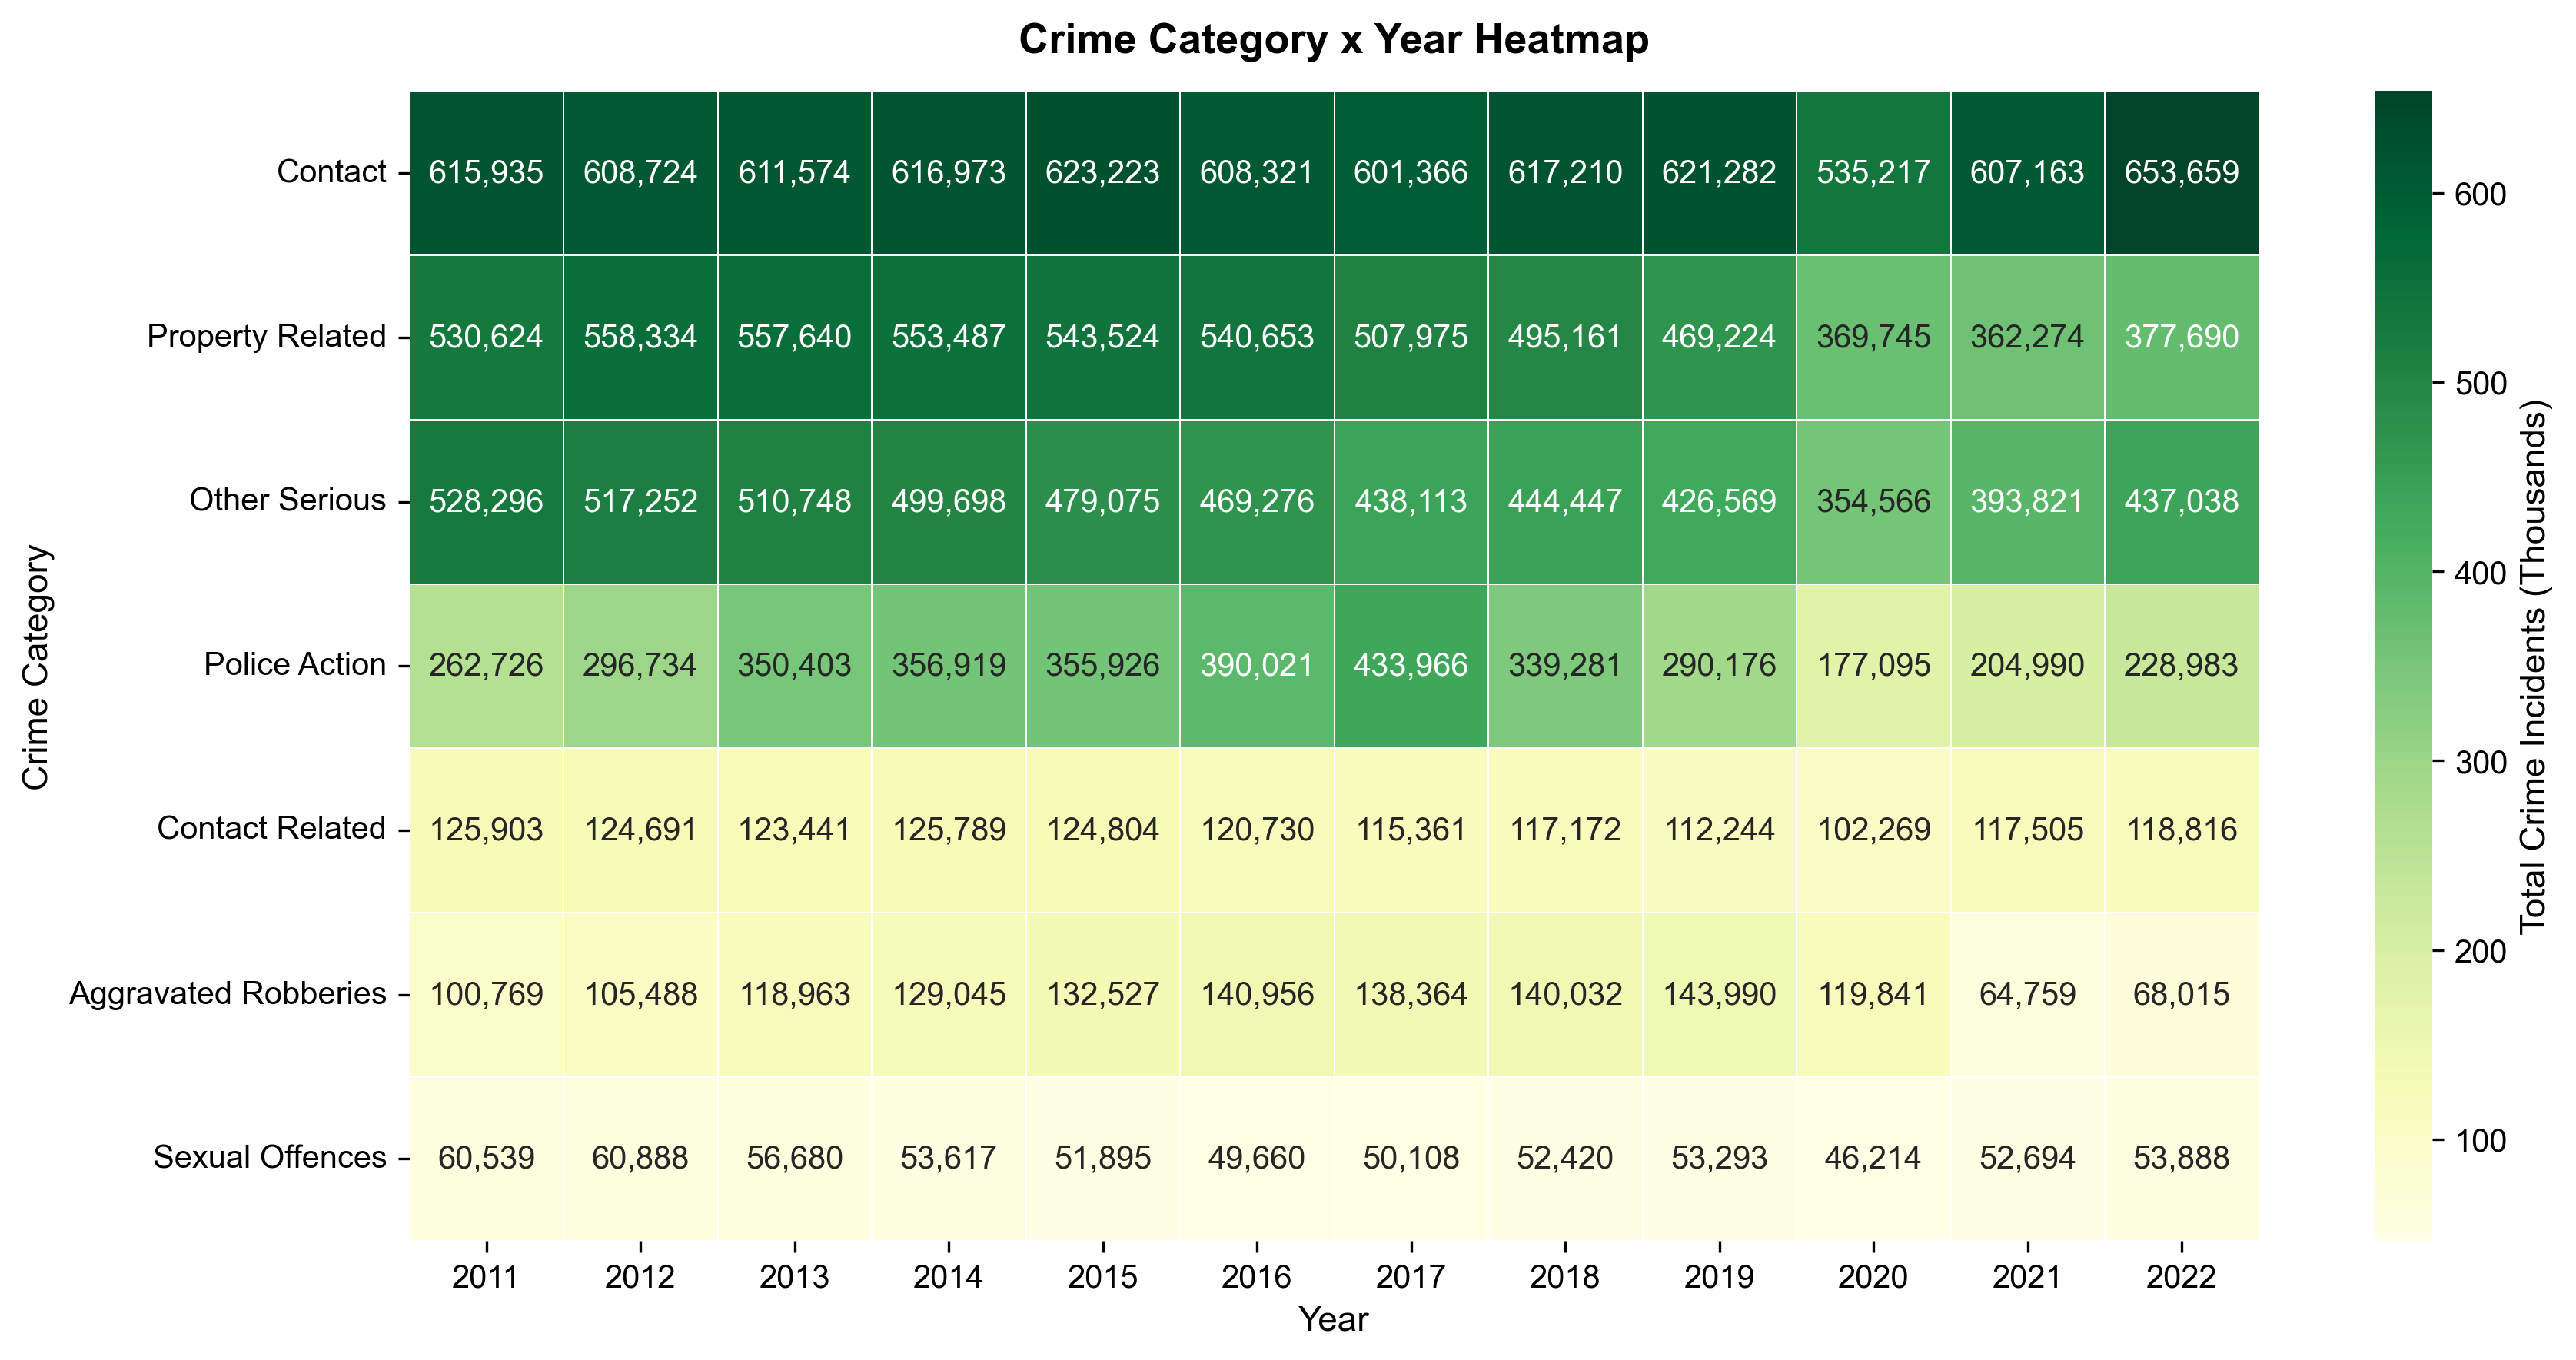

In [20]:
fig4, ax4 = plt.subplots(figsize = (12,6))

sns.heatmap(category_year_df,
            cmap = 'YlGn',              # yellow-green colour map
            fmt = ',d',                 # integer format            
            annot = True,                 
            annot_kws = {'size': 10},
            linewidth = 0.4,
            ax = ax4)

# chart formatting:
ax4.set_xlabel('Year', fontsize = 11)
ax4.set_ylabel('Crime Category', fontsize = 11)
ax4.set_title('Crime Category x Year Heatmap', fontsize = 13, fontweight = 'bold', pad = 12)

colour_bar = ax4.collections[0].colorbar                           # retrieves colour bar
colour_bar.ax.yaxis.set_major_formatter(label_fmt_3)               # calls upon global axis formatting option 3 for colour bar ticks
colour_bar.set_label('Total Crime Incidents (Thousands)', fontsize = 11)  

plt.tight_layout()  
plt.savefig('reports/figures/category_year_heatmap.png', dpi = 300, bbox_inches = 'tight')
plt.show()

The output of this notebook is as follows: four visualisations `province_bar_chart.png`, `national_crime_trend.png`, `top5_categories.png`, and `category_year_heatmap.png`, all of which are saved to `reports/figures/`. All 4 outputs are ready for use in subsequent pipeline stages.